# Data Augmentation 비교실험 — Mixup / CutMix

## 프로젝트 목적

Ex02에서 직접 구현한 **ResNet-50(Bottleneck 기반, 사전학습 없음)** 을 그대로 가져와,
데이터 증강 4가지 설정의 효과를 동일 조건에서 비교한다.

Ex02가 **모델 구조 쪽 정규화(residual connection)** 를 검증했다면,
이번 프로젝트는 같은 모델 위에서 **데이터 쪽 정규화(augmentation)** 를 검증한다.

## 비교 대상 (4개)

| 실험 이름 | 학습셋 이미지 단위 변형 | 배치 단위 심화 증강 |
|---|---|---|
| `no_aug` | resize + normalize만 | — |
| `basic_aug` | + RandomResizedCrop / HFlip / ColorJitter | — |
| `basic_mixup` | 기본 증강 | Mixup (α=0.2, p=0.5) |
| `basic_cutmix` | 기본 증강 | CutMix (α=1.0, p=0.5) |

## 데이터 분할 (Ex02와 동일한 규율)

- **train / val / test 3분할**, 모두 층화(stratified).
- 학습 중 성능 비교는 **validation** 으로 한다(= 증강 비교표 기준).
- **test 는 4개 실험이 모두 끝난 뒤 딱 한 번만** 확인한다.

## 가설

이 실험은 **사전학습 가중치를 쓰지 않는다.** 120개 견종 fine-grained 분류를 9,600장으로
처음부터 학습하므로 과적합이 크게 일어날 것이다(train acc ≫ val acc).
증강의 본질이 정규화이므로, **이 조건에서 증강의 효과가 뚜렷하게 드러날 것**이다.

> 사전학습 ResNet-50을 쓰면 Stanford Dogs가 ImageNet의 부분집합이라 몇 epoch만에
> 높은 정확도에 도달하고, 증강 간 차이가 노이즈에 묻혀 비교 자체가 무의미해진다.
> from-scratch 조건을 택한 이유가 여기에 있다.

## 목차

0. 실행 환경 / 재현성
1. 데이터 준비 (Stanford Dogs, 120클래스) + 층화 3분할
2. 증강 파이프라인 — 이미지 단위
3. 증강 파이프라인 — 배치 단위 (Mixup / CutMix) ★ 핵심 ★
4. 모델 (Ex02 구현 재사용) + soft label과 손실 함수
5. 학습 · 평가 함수 (soft label 대응으로 확장)
6. 비교실험 본 실험 (4회)
7. 결과표 및 학습 과정 시각화 (validation 기준)
8. 최종 평가 (test) + 추가 실험
9. 결과 분석 및 문제점
10. 디버깅 기록
11. 회고 / 전체 실행 플로우

## 0. 실행 환경 / 재현성

In [1]:
# 실행 환경 확인
import torch
print('GPU:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('이름:', torch.cuda.get_device_name(0))
    print('메모리:', f'{torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
print('torch:', torch.__version__)

# soft label(확률 벡터)을 nn.CrossEntropyLoss에 직접 넘기려면 torch 1.10 이상이 필요하다.
assert tuple(int(v) for v in torch.__version__.split('.')[:2]) >= (1, 10), \
    'soft target 지원은 torch 1.10부터입니다. 4절의 SoftTargetCrossEntropy를 대신 쓰세요.'

GPU: True
이름: Tesla T4
메모리: 14.6 GB
torch: 2.11.0+cu128


In [2]:
# 재현성 시드 고정 (초기 가중치 / 셔플 / 데이터 분할의 무작위성을 잡는다)
import random, numpy as np

SEED = 42

def set_seed(seed: int = SEED, strict: bool = False) -> None:
    """난수 생성기를 모두 고정해 실험을 재현 가능하게 만든다.

    Args:
        seed: 고정할 시드값.
        strict: True면 cuDNN을 결정론 모드로 둔다. 완전 재현은 되지만
            알고리즘 자동 탐색이 막혀 학습이 느려진다. 이번 프로젝트는
            4개 실험 × 25 epoch을 돌려야 하므로 기본값을 False로 두었다.
            초기 가중치·데이터 분할·셔플 순서는 seed로 이미 통일되므로
            실험 간 비교 공정성에는 영향이 없다.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = strict
    torch.backends.cudnn.benchmark = not strict

set_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('seed 고정 완료:', SEED, '| device:', device)

seed 고정 완료: 42 | device: cuda


In [3]:
# 실험 전역 설정 — 4개 실험이 증강을 제외한 모든 조건을 공유해야 비교가 유효하다.
# 값을 한 곳에 모아 두면 "실험 하나만 실수로 다른 설정"이 되는 사고를 막을 수 있다.
IMG_SIZE    = 128      # Ex02는 224였으나, from-scratch 학습을 충분히 돌리기 위해 축소
BATCH_SIZE  = 64
EPOCHS      = 25       # 사전학습이 없으므로 Ex02의 5 epoch보다 훨씬 길게 필요하다
LR          = 1e-3     # Ex02와 동일하게 Adam 사용
VAL_RATIO   = 0.2
N_TRAINVAL  = 12000    # Stanford Dogs 공식 학습셋 크기 (나머지 8,580장은 test)
MIXUP_ALPHA  = 0.2     # Mixup 논문(ImageNet) 권장값
CUTMIX_ALPHA = 1.0     # CutMix 논문 권장값
APPLY_PROB   = 0.5     # 배치 단위로 심화 증강을 적용할 확률
MEAN = (0.485, 0.456, 0.406)   # ImageNet 표준값 (Ex02와 동일)
STD  = (0.229, 0.224, 0.225)

# --- 데이터 로딩 속도 설정 (실험 조건 자체에는 영향 없음, 로딩 방식만 바꾼다) ---
import os
NUM_WORKERS     = min(8, (os.cpu_count() or 2))  # DataLoader 병렬 디코딩 프로세스 수
USE_IMAGE_CACHE = True   # True면 이미지를 최초 1회만 디코딩해 RAM에 캐시 → epoch마다 재디코딩 제거
CACHE_SHORT     = 160    # 캐시에 저장할 이미지 짧은 변(px). 증강은 이 크기에서 시작한다(아래 설명 참고).
# 주의: 캐시는 원본을 CACHE_SHORT로 미리 축소해 담으므로, 증강 실험의 절대 정확도가
#       캐시 없이 원해상도에서 증강할 때와 미세하게 달라질 수 있다. 단 4개 실험 모두
#       같은 캐시를 쓰므로 '실험 간 비교'의 공정성은 그대로 유지된다.
#       원해상도 그대로 쓰고 싶으면 USE_IMAGE_CACHE=False 로 두면 된다(느려짐).

from pathlib import Path
RESULT_DIR = Path('results')          # 학습 히스토리와 best 가중치 저장 위치
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print(f'{IMG_SIZE}px | batch {BATCH_SIZE} | {EPOCHS} epochs | lr {LR} '
      f'| workers {NUM_WORKERS} | cache {USE_IMAGE_CACHE}')

128px | batch 64 | 25 epochs | lr 0.001 | workers 2 | cache True


## 1. 데이터 준비 (Stanford Dogs, 120클래스)

Stanford Dogs는 120견종 20,580장이며, 여기서는 **허깅페이스 `datasets`에서 직접 내려받는다**(로컬 다운로드·압축 해제·경로 탐색 불필요).
Ex02의 `PetHF`와 같은 역할을 하는 래퍼를 만들되, 이번에는 허깅페이스 데이터셋을 `ImageFolder` 인터페이스로 감싼 어댑터(`HFImageFolder`) 기반이다.

**핵심 설계: split마다 transform을 분리한다.** `random_split`이 돌려주는 `Subset`은
원본 Dataset의 transform을 공유하기 때문에, 학습셋에 증강을 걸면 **val/test에도 무작위
변형이 적용되어 평가가 오염된다.** 로그만 보면 원인을 찾기 어려운 함정이라 구조로 막았다.

In [4]:
import math
from pathlib import Path
from typing import Callable, Sequence, Tuple

import numpy as np
from PIL import Image
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset

# Stanford Dogs를 허깅페이스에서 바로 내려받는다 (로컬 압축 해제·경로 하드코딩 불필요).
try:
    from datasets import load_dataset, concatenate_datasets
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'datasets'], check=True)
    from datasets import load_dataset, concatenate_datasets

# parquet 기반 저장소라 trust_remote_code가 필요 없고, 20,580장·120클래스를 그대로 제공한다.
HF_REPO_ID = 'Donghyun99/Stanford-Dogs'


class HFImageFolder:
    """허깅페이스 이미지 데이터셋을 torchvision ImageFolder처럼 감싸는 어댑터.

    아래 DogsFolder가 기대하는 최소 인터페이스만 노출한다.
      - classes : 클래스 이름 리스트 (len == 120)
      - samples : (row_idx, label) 리스트  → 'path' 자리에 HF 행 인덱스를 넣는다
      - loader  : row_idx -> PIL.Image(RGB)  (행 단위 지연 로딩)

    파일 경로 대신 '행 인덱스'를 핸들로 쓰기 때문에, 뒤쪽 DogsFolder 코드를 한 줄도
    바꾸지 않고 그대로 재사용할 수 있다.

    [속도] cache가 채워지면 loader가 디코딩 없이 RAM의 uint8을 바로 돌려준다.
    epoch마다 같은 JPEG를 다시 디코딩하던 병목이 사라진다(build_image_cache 참고).

    Args:
        hf_dataset: datasets.Dataset (image/label 컬럼 보유).
        class_names: 라벨 인덱스 순서와 일치하는 클래스 이름 리스트.
        image_col, label_col: 이미지/라벨 컬럼 이름.
    """

    def __init__(self, hf_dataset, class_names: Sequence[str],
                 image_col: str = 'image', label_col: str = 'label'):
        self.ds = hf_dataset
        self.image_col = image_col
        self.classes = list(class_names)
        self.cache = None    # build_image_cache가 채우면 list[np.uint8 HxWx3]
        # 라벨만 컬럼 단위로 읽으므로 이미지 디코딩이 일어나지 않는다(전체 스캔이 빠르다).
        self.samples = [(i, int(lb)) for i, lb in enumerate(hf_dataset[label_col])]

    def loader(self, row_idx: int):
        """행 인덱스로 이미지를 로딩한다 (캐시가 있으면 디코딩 없이 즉시 반환)."""
        if self.cache is not None:
            return Image.fromarray(self.cache[int(row_idx)])   # 이미 RGB
        img = self.ds[int(row_idx)][self.image_col]
        return img if img.mode == 'RGB' else img.convert('RGB')


def build_image_cache(base: 'HFImageFolder', short: int = None) -> None:
    """모든 이미지를 최초 1회만 디코딩·축소해 RAM(uint8)에 담는다.

    이후 매 epoch JPEG 디코딩을 반복하지 않으므로 데이터 로딩이 크게 빨라진다.
    짧은 변을 short px로 줄여 저장하며(확대는 하지 않음), 증강은 이 이미지에서 시작한다.
    순차 접근(enumerate)이 무작위 인덱싱보다 빨라서 빌드도 그만큼 덜 걸린다.
    """
    short = short if short is not None else CACHE_SHORT
    n = len(base.ds)
    cache = [None] * n
    for i, ex in enumerate(base.ds):
        img = ex[base.image_col]
        if img.mode != 'RGB':
            img = img.convert('RGB')
        w, h = img.size
        s = short / min(w, h)
        if s < 1.0:                              # 이미 작으면 그대로 둔다
            img = img.resize((max(1, round(w * s)), max(1, round(h * s))))
        cache[i] = np.asarray(img, dtype=np.uint8)
        if (i + 1) % 4000 == 0:
            print(f'  캐시 생성 {i + 1}/{n}')
    base.cache = cache
    mb = sum(a.nbytes for a in cache) / 1024 ** 2
    print(f'이미지 캐시 완료: {n}장, 약 {mb:.0f} MB (RAM)')


def load_stanford_dogs_hf(repo_id: str = HF_REPO_ID) -> HFImageFolder:
    """허깅페이스에서 Stanford Dogs를 내려받아 ImageFolder 호환 어댑터로 반환한다.

    저장소는 공식 분할(train 12,000 / test 8,580)로 오지만, 이 프로젝트는 Ex02와 동일하게
    '전체 20,580장을 하나로 모아 직접 층화 3분할'하므로 두 split을 합쳐서 돌려준다.
    (이후 stratified_split이 train/val/test를 다시 나눈다.)
    """
    dsets = load_dataset(repo_id)                       # 예: {'train': ..., 'test': ...}
    full = concatenate_datasets([dsets[s] for s in dsets.keys()])
    class_names = full.features['label'].names          # 120개 견종 이름
    return HFImageFolder(full, class_names)


class DogsFolder(Dataset):
    """Stanford Dogs를 split별 transform과 함께 감싸는 래퍼. (Ex02 PetHF와 같은 역할)

    indices로 부분집합을 지정하고, transform은 이 객체가 독립적으로 갖는다.
    → 하나의 원본에서 train/val/test를 잘라 내면서도 학습셋에만 증강을 적용할 수 있다.
    흑백(1채널) 이미지는 RGB로 변환해 채널을 통일한다.

    Args:
        base: HFImageFolder(또는 .samples/.loader/.classes를 제공하는 ImageFolder 호환 객체).
        indices (Sequence[int]): 사용할 원본 인덱스.
        transform: 적용할 torchvision 전처리.
    """

    def __init__(self, base, indices: Sequence[int], transform: Callable):
        self.samples = [base.samples[i] for i in indices]
        self.loader = base.loader
        self.transform = transform
        self.classes = base.classes

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, i: int) -> Tuple[torch.Tensor, int]:
        handle, label = self.samples[i]     # handle = HF 행 인덱스 (기존 path 자리)
        img = self.loader(handle)
        if img.mode != 'RGB':               # 흑백 이미지 방어 처리
            img = img.convert('RGB')
        return self.transform(img), label

### 1-1. 층화 3분할 (train / val / test)

Ex02와 동일한 규율을 유지한다.

1. 전체 20,580장을 층화 분할해 **test 8,580장**을 먼저 떼어 낸다(과제 명세의 평가셋 크기).
2. 남은 **12,000장**을 다시 층화 80/20으로 나눠 **train 9,600 / val 2,400** 을 만든다.
3. **val**: 학습 중 증강 비교 기준. **test**: 4개 실험이 끝난 뒤 최종 확인용.

층화하지 않으면 120개 견종 중 일부가 한쪽에 쏠려, 증강 효과와 분할 운을 구분할 수 없게 된다.

In [5]:
def stratified_split(labels: np.ndarray, n_keep: int, seed: int = SEED
                     ) -> Tuple[np.ndarray, np.ndarray]:
    """클래스 비율을 유지하며 인덱스를 (keep, rest)로 나눈다.

    클래스별로 같은 비율만큼 뽑아 담기 때문에, 어떤 견종도 한쪽에만 쏠리지 않는다.
    seed가 고정되어 있어 4개 실험이 완전히 동일한 분할을 사용한다.

    Args:
        labels: 전체 라벨 배열.
        n_keep: keep 쪽에 담을 총 개수.
        seed: 셔플 시드.

    Returns:
        (keep_idx, rest_idx)
    """
    rng = np.random.default_rng(seed)
    ratio = n_keep / len(labels)
    keep, rest = [], []
    for c in np.unique(labels):
        idx_c = np.where(labels == c)[0]
        rng.shuffle(idx_c)
        n_c = int(round(len(idx_c) * ratio))
        keep.extend(idx_c[:n_c])
        rest.extend(idx_c[n_c:])
    return np.array(keep), np.array(rest)


base_ds = load_stanford_dogs_hf()                     # 허깅페이스에서 다운로드 (transform 없이, 래퍼가 담당)

# 이미지를 최초 1회만 디코딩해 RAM에 캐시 → 이후 학습/평가 내내 재디코딩이 사라진다.
# (다운로드 자체는 최초 1회만 일어나고 datasets가 캐시하므로, 반복 비용은 '디코딩'이다.)
if USE_IMAGE_CACHE:
    print('이미지 캐시 생성 중... (최초 1회, 수 분 소요될 수 있음)')
    build_image_cache(base_ds)

labels_all = np.array([lb for _, lb in base_ds.samples])
NUM_CLASSES = len(base_ds.classes)

trainval_idx, test_idx = stratified_split(labels_all, N_TRAINVAL, SEED)
tv_labels = labels_all[trainval_idx]
sub_train, sub_val = stratified_split(tv_labels, int(len(trainval_idx) * (1 - VAL_RATIO)), SEED)
train_idx, val_idx = trainval_idx[sub_train], trainval_idx[sub_val]

print('데이터 출처 :', HF_REPO_ID)
print('클래스 수   :', NUM_CLASSES)
print(f'train {len(train_idx)} | val {len(val_idx)} | test {len(test_idx)}')
print('겹침 검사 (모두 0이어야 정상):',
      len(set(train_idx) & set(val_idx)),
      len(set(train_idx) & set(test_idx)),
      len(set(val_idx) & set(test_idx)))

# 층화 확인: 클래스별 개수 분포가 고르게 나뉘었는지
for name, idx in [('train', train_idx), ('val', val_idx), ('test', test_idx)]:
    cnt = np.bincount(labels_all[idx], minlength=NUM_CLASSES)
    print(f'{name:5s} 클래스별 개수  min {cnt.min():3d} / max {cnt.max():3d} / mean {cnt.mean():6.1f}')

README.md:   0%|          | 0.00/4.31k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  455MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  321MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/12000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8580 [00:00<?, ? examples/s]

이미지 캐시 생성 중... (최초 1회, 수 분 소요될 수 있음)
  캐시 생성 4000/20580
  캐시 생성 8000/20580
  캐시 생성 12000/20580
  캐시 생성 16000/20580
  캐시 생성 20000/20580
이미지 캐시 완료: 20580장, 약 2022 MB (RAM)
데이터 출처 : Donghyun99/Stanford-Dogs
클래스 수   : 120
train 9600 | val 2399 | test 8581
겹침 검사 (모두 0이어야 정상): 0 0 0
train 클래스별 개수  min  69 / max 118 / mean   80.0
val   클래스별 개수  min  17 / max  29 / mean   20.0
test  클래스별 개수  min  62 / max 105 / mean   71.5


## 2. 증강 파이프라인 — 이미지 단위

`eval_tf`는 무작위성이 전혀 없으며 **val/test 전용**이자 `no_aug` 실험의 학습셋 전처리다.

`RandomVerticalFlip`은 의도적으로 제외했다. 개 사진은 좌우를 뒤집어도 라벨이 유효하지만,
위아래가 뒤집힌 개 사진은 평가 데이터에 존재하지 않는 형태다.
**증강 선택 기준은 "평가 환경에 실제로 있을 법한 변형인가"** 이며, 이 기준이 없으면
데이터를 늘리는 게 아니라 노이즈를 주입하게 된다.

In [6]:
eval_tf = T.Compose([                       # val·test 공용 + no_aug 학습셋
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

basic_aug_tf = T.Compose([                  # 기본 증강 (학습셋 전용)
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),   # 국소 특징을 다양한 스케일로 보게
    T.RandomHorizontalFlip(p=0.5),                     # 라벨을 보존하는 안전한 변형
    T.ColorJitter(brightness=0.3, contrast=0.2, saturation=0.2),  # 조명 차이 대응
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])


def build_loaders(train_transform: Callable) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """학습셋 transform만 바꿔 3개 DataLoader를 만든다.

    val/test는 항상 eval_tf를 쓰므로, 증강 설정을 바꿔도 평가 조건은 절대 변하지 않는다.
    shuffle은 학습셋에만 적용한다(val/test 순서 고정 → 나중에 오분류 분석에 활용).

    [속도] num_workers를 CPU 수에 맞춰 늘리고, persistent_workers로 epoch마다 워커를
    재생성하지 않게 했다(첫 epoch 지연·워커 재시작 오버헤드 완화). prefetch_factor로
    GPU가 다음 배치를 미리 받아 두게 한다. 데이터 '내용'은 전혀 바뀌지 않는다.
    """
    g = torch.Generator(); g.manual_seed(SEED)

    def seed_worker(worker_id):
        ws = torch.initial_seed() % 2 ** 32
        np.random.seed(ws); random.seed(ws)

    common = dict(num_workers=NUM_WORKERS, pin_memory=(device == 'cuda'))
    if NUM_WORKERS > 0:                       # 워커가 있을 때만 유효한 옵션들
        common.update(persistent_workers=True, prefetch_factor=4)

    tr = DataLoader(DogsFolder(base_ds, train_idx, train_transform),
                    batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                    worker_init_fn=seed_worker, generator=g, **common)
    va = DataLoader(DogsFolder(base_ds, val_idx, eval_tf),
                    batch_size=BATCH_SIZE * 2, shuffle=False, **common)
    te = DataLoader(DogsFolder(base_ds, test_idx, eval_tf),
                    batch_size=BATCH_SIZE * 2, shuffle=False, **common)
    return tr, va, te


# sanity check: 한 장 꺼내 shape/값범위 확인 (Ex02와 동일한 점검)
_tr, _va, _te = build_loaders(basic_aug_tf)
img, label = _tr.dataset[0]
print('이미지 shape:', tuple(img.shape))
print('값 범위: %.2f ~ %.2f' % (img.min(), img.max()))
print('배치 shape:', tuple(next(iter(_tr))[0].shape))

이미지 shape: (3, 128, 128)
값 범위: -1.96 ~ 2.64
배치 shape: (64, 3, 128, 128)


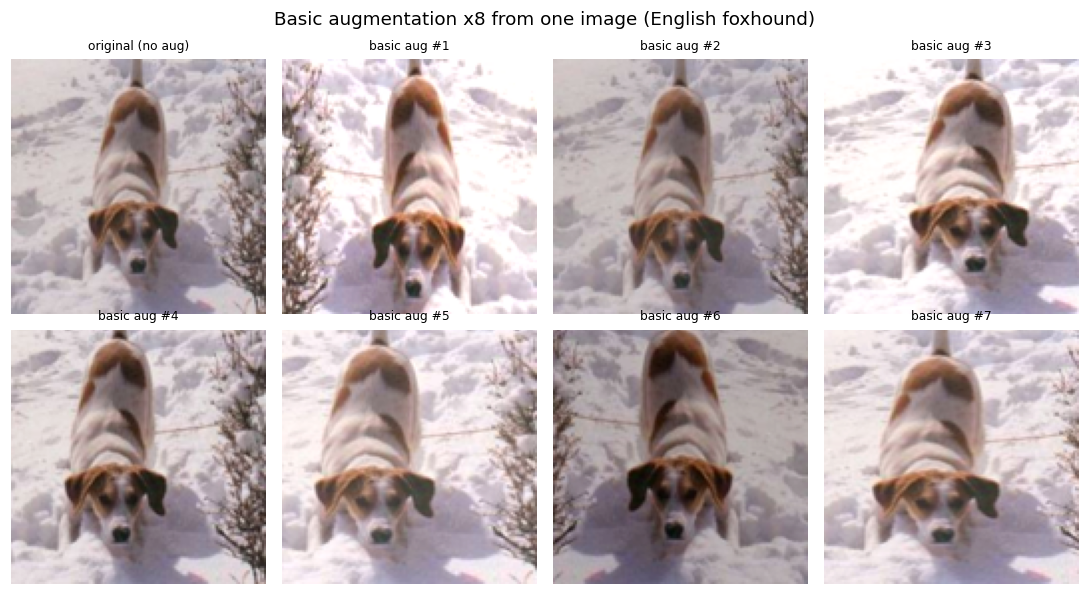

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'DejaVu Sans'      # 한글 폰트 미설치 환경 대비
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 110


def denormalize(t: torch.Tensor) -> torch.Tensor:
    """Normalize를 되돌려 0~1 범위로 복원한다 (시각화 전용).

    normalize된 텐서를 그대로 imshow하면 값이 [0,1]을 벗어나 색이 뭉개진다.
    """
    m = torch.tensor(MEAN).view(-1, 1, 1)
    s = torch.tensor(STD).view(-1, 1, 1)
    return (t.detach().cpu() * s + m).clamp(0, 1)


def short_name(cls: str, width: int = 12) -> str:
    """'n02085620-Chihuahua' -> 'Chihuahua' 로 축약 (그래프 라벨 가독성)."""
    return cls.split('-')[-1].replace('_', ' ')[:width]


def show_images(tensors, titles, ncols: int = 4, unit: float = 2.5, suptitle=None) -> None:
    """이미지 텐서 목록을 grid로 출력한다 (내부에서 denormalize 처리)."""
    n = len(tensors)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(unit * ncols, unit * nrows + 0.5))
    flat = np.atleast_1d(np.array(axes)).ravel()
    for ax, im, ti in zip(flat, tensors, titles):
        ax.imshow(denormalize(im).permute(1, 2, 0).numpy())
        ax.set_title(ti, fontsize=8)
        ax.axis('off')
    for ax in flat[n:]:
        ax.axis('off')
    if suptitle:
        fig.suptitle(suptitle, fontsize=12)
    plt.tight_layout(); plt.show()


# 같은 원본 1장에 기본 증강을 8회 적용해 무작위성이 실제로 작동하는지 확인
set_seed(SEED)
_path, _lb = base_ds.samples[train_idx[7]]
_pil = base_ds.loader(_path).convert('RGB')
show_images([eval_tf(_pil)] + [basic_aug_tf(_pil) for _ in range(7)],
            ['original (no aug)'] + [f'basic aug #{i+1}' for i in range(7)],
            suptitle=f'Basic augmentation x8 from one image ({short_name(base_ds.classes[_lb], 20)})')

## 3. 증강 파이프라인 — 배치 단위 (Mixup / CutMix) ★ 핵심 ★

아래 `rand_bbox`·`cutmix_batch`가 이 프로젝트에서 **가장 핵심적이고 틀리기 쉬운 부분**이다.
기본 증강과의 결정적 차이는 **이미지 두 장을 조합하고, 그에 맞춰 라벨도 섞는다**는 점이다.
라벨이 one-hot이 아닌 **soft label(확률 벡터)** 이 되므로 손실 함수 쪽도 함께 바뀐다.

### 반드시 짚어야 할 함정

`lam`은 *바탕 이미지가 남는 비율*이므로 잘라낼 영역의 한 변 비율은 `sqrt(1 - lam)`이다.
그런데 박스 중심을 균등분포로 뽑고 경계에서 clip하기 때문에,
**박스가 이미지 경계에 걸리면 실제 잘린 면적이 의도한 `1 - lam`보다 작아진다.**
224×224에서 2,000회 샘플링한 실측값:

| 뽑은 lam | 의도한 잘림 비율 | 실제 잘림 비율(평균) |
|---|---|---|
| 0.95 | 0.050 | 0.045 |
| 0.50 | 0.500 | 0.337 |
| 0.05 | 0.950 | 0.543 |

그래서 라벨을 섞을 때는 뽑은 `lam`이 아니라 **반환된 좌표로 면적을 다시 계산한
`lam_adjusted`** 를 써야 한다. 이걸 놓치면 이미지와 라벨의 비율이 어긋나 성능이 떨어진다.

In [8]:
import torch.nn.functional as F


def rand_bbox(height: int, width: int, lam: float, rng=None) -> Tuple[int, int, int, int]:
    """CutMix용 바운딩 박스 좌표 (y1, y2, x1, x2)를 무작위로 뽑는다.

    작동 원리:
        lam이 '바탕 이미지가 남는 비율'이므로, 잘라낼 영역의 한 변 비율은 sqrt(1-lam).
        중심점을 균등분포로 뽑고 이미지 경계에서 clip한다.

    Note:
        경계 clip 때문에 실제 잘린 면적은 (1 - lam)보다 작아질 수 있다.
        라벨 혼합 비율은 반드시 이 함수가 돌려준 좌표로 재계산해야 한다.

    Args:
        height, width: 대상 이미지 크기. 인자로 받으므로 정사각형이 아니어도 동작한다.
        lam: 바탕 이미지가 남는 비율.
        rng: 재현성이 필요할 때 주입할 난수 생성기.
    """
    rng = rng if rng is not None else np.random
    cut_ratio = math.sqrt(max(0.0, 1.0 - lam))
    cut_h, cut_w = int(height * cut_ratio), int(width * cut_ratio)
    cy, cx = int(rng.randint(height)), int(rng.randint(width))
    y1, y2 = np.clip([cy - cut_h // 2, cy + cut_h // 2], 0, height)
    x1, x2 = np.clip([cx - cut_w // 2, cx + cut_w // 2], 0, width)
    return int(y1), int(y2), int(x1), int(x2)


def mix_2_images(image_a: torch.Tensor, image_b: torch.Tensor, lam: float, rng=None
                 ) -> Tuple[torch.Tensor, float]:
    """이미지 두 장을 CutMix 방식으로 섞고 '실제' 혼합 비율을 함께 반환한다.

    바탕 image_a에서 바운딩 박스 바깥쪽을 유지하고, 박스 안쪽만 image_b에서 가져와 덮어쓴다.

    Returns:
        (mixed_image, lam_adjusted). lam_adjusted는 결과에서 image_a가 차지하는
        실제 면적 비율이며, 라벨 혼합에는 반드시 이 값을 쓴다.
    """
    _, h, w = image_a.shape
    y1, y2, x1, x2 = rand_bbox(h, w, lam, rng)
    mixed = image_a.clone()
    mixed[:, y1:y2, x1:x2] = image_b[:, y1:y2, x1:x2]
    return mixed, 1.0 - ((y2 - y1) * (x2 - x1) / (h * w))


def mix_2_labels(label_a: int, label_b: int, lam: float, num_classes: int) -> torch.Tensor:
    """정수 라벨 두 개를 비율 lam으로 섞어 soft label을 만든다.

    결과는 one-hot이 아니라 두 클래스 인덱스에 lam, (1-lam)이 배분된 확률 벡터다.
    예) lam=0.6 -> [.., 0.6(A), .., 0.4(B), ..]
    """
    oh_a = F.one_hot(torch.as_tensor(label_a), num_classes).float()
    oh_b = F.one_hot(torch.as_tensor(label_b), num_classes).float()
    return lam * oh_a + (1.0 - lam) * oh_b


# 구현 검증: 뽑은 lam과 실제 면적이 다르고, 라벨은 실제 면적을 따라가는지 확인
set_seed(SEED)
_ds_probe = DogsFolder(base_ds, train_idx, eval_tf)
img_a, lb_a = _ds_probe[3]
img_b, lb_b = _ds_probe[11]
for target in (0.9, 0.5, 0.2):
    mixed, lam_real = mix_2_images(img_a, img_b, target)
    soft = mix_2_labels(lb_a, lb_b, lam_real, NUM_CLASSES)
    print(f'뽑은 lam {target:.2f} -> 실제 면적비 {lam_real:.3f} | '
          f'soft label 합 {soft.sum():.4f}, 0이 아닌 원소 {int((soft > 0).sum())}개')

뽑은 lam 0.90 -> 실제 면적비 0.902 | soft label 합 1.0000, 0이 아닌 원소 1개
뽑은 lam 0.50 -> 실제 면적비 0.708 | soft label 합 1.0000, 0이 아닌 원소 1개
뽑은 lam 0.20 -> 실제 면적비 0.450 | soft label 합 1.0000, 0이 아닌 원소 1개


### 3-1. 배치 단위 구현

실제 학습에서는 배치를 무작위로 섞은 인덱스(`perm`)와 원본을 짝지어, **추가 데이터 로딩 없이
배치 내부에서 쌍을 만든다.** 논문 구현과 동일하게 바운딩 박스는 배치 전체에 한 번만 적용해
텐서 슬라이싱 1회로 처리한다(속도 이점).

`APPLY_PROB`으로 배치마다 확률적으로만 적용한다. 항상 적용하면 모델이 섞이지 않은 원본
샘플을 한 번도 보지 못해 학습이 불안정해질 수 있다.

In [9]:
def mixup_batch(images: torch.Tensor, labels: torch.Tensor, num_classes: int
                ) -> Tuple[torch.Tensor, torch.Tensor]:
    """배치 단위 Mixup. 픽셀 값 자체를 lam 비율로 선형 결합한다.

    CutMix가 '공간적으로 잘라 붙이기'라면 Mixup은 '값 자체를 블렌딩'하는 방식이라
    바운딩 박스 계산이 필요 없고, 뽑은 lam을 라벨에 그대로 쓸 수 있다.

    Returns:
        (mixed_images, soft_labels). 확률에 걸리지 않은 배치는 원본 + one-hot을
        그대로 돌려주므로, 호출부는 분기 없이 항상 soft label을 받는다.
    """
    onehot = F.one_hot(labels, num_classes).float()
    if np.random.rand() > APPLY_PROB:
        return images, onehot
    lam = float(np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA))
    perm = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1.0 - lam) * images[perm]
    return mixed, lam * onehot + (1.0 - lam) * onehot[perm]


def cutmix_batch(images: torch.Tensor, labels: torch.Tensor, num_classes: int
                 ) -> Tuple[torch.Tensor, torch.Tensor]:
    """배치 단위 CutMix. 영역을 잘라 붙이고 '실제 면적'으로 라벨을 섞는다.

    Returns:
        (mixed_images, soft_labels). mixup_batch와 동일한 인터페이스이므로
        학습 루프에서 둘을 그대로 교체해 끼울 수 있다.
    """
    onehot = F.one_hot(labels, num_classes).float()
    if np.random.rand() > APPLY_PROB:
        return images, onehot

    lam = float(np.random.beta(CUTMIX_ALPHA, CUTMIX_ALPHA))
    perm = torch.randperm(images.size(0), device=images.device)
    _, _, h, w = images.shape
    y1, y2, x1, x2 = rand_bbox(h, w, lam)

    mixed = images.clone()
    mixed[:, :, y1:y2, x1:x2] = images[perm][:, :, y1:y2, x1:x2]

    # ← 뽑은 lam이 아니라 실제로 잘린 면적으로 라벨 비율을 재계산 (가장 틀리기 쉬운 지점)
    lam_adj = 1.0 - ((y2 - y1) * (x2 - x1) / (h * w))
    return mixed, lam_adj * onehot + (1.0 - lam_adj) * onehot[perm]

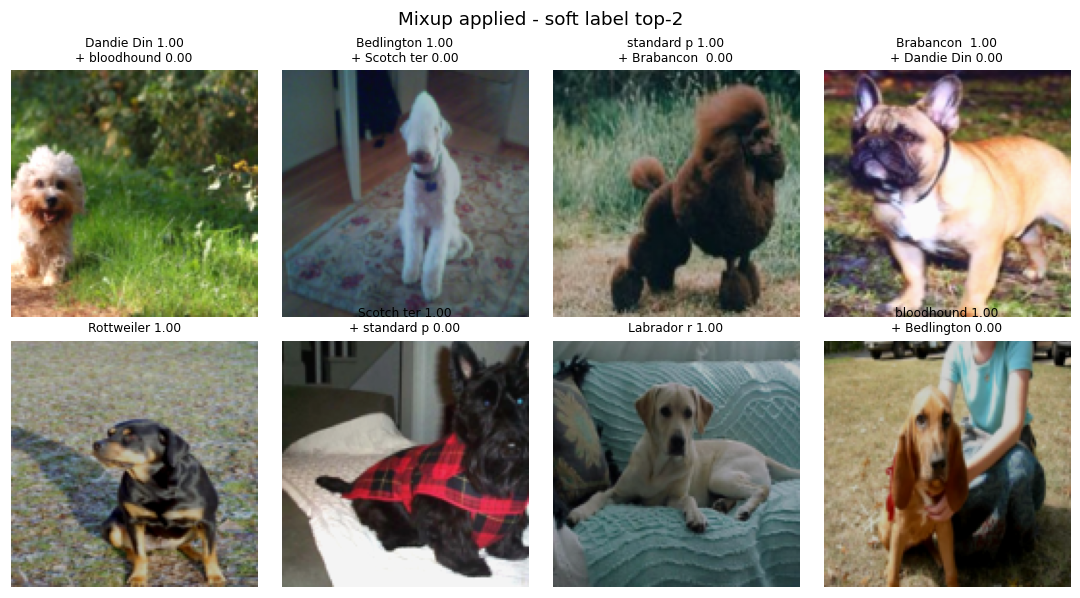

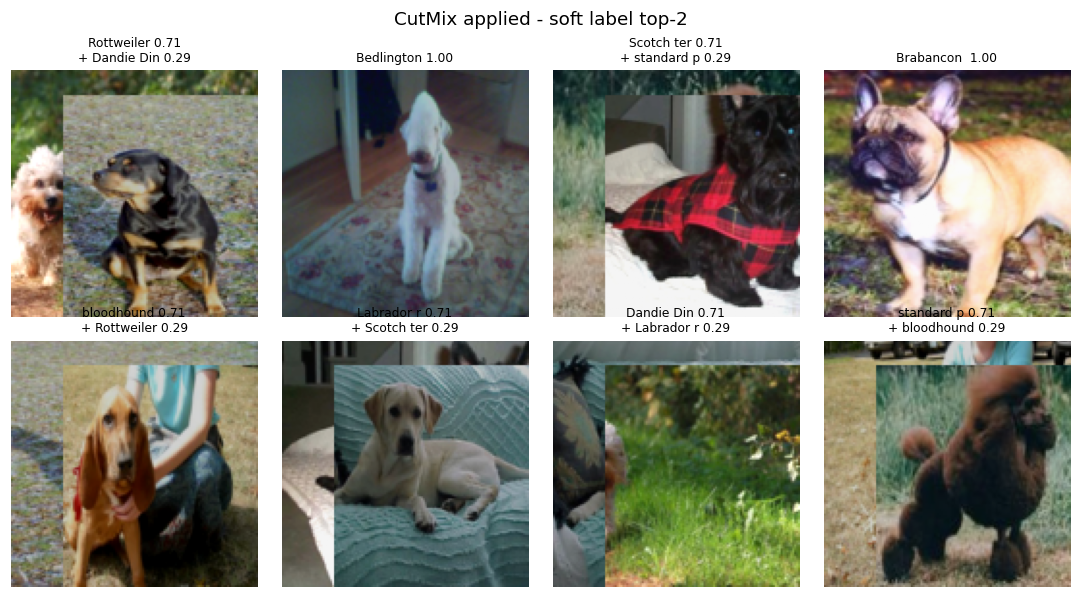

APPLY_PROB 복원: 0.5


In [10]:
# Mixup / CutMix 적용 결과 시각화 — soft label 상위 2개 클래스와 비율을 제목에 표기
set_seed(SEED + 1)
_vis_loader = DataLoader(DogsFolder(base_ds, train_idx, basic_aug_tf), batch_size=8, shuffle=True)
_imgs, _lbls = next(iter(_vis_loader))

_saved_prob, APPLY_PROB = APPLY_PROB, 1.0     # 시각화에서는 항상 적용
for name, fn in (('Mixup', mixup_batch), ('CutMix', cutmix_batch)):
    mixed, soft = fn(_imgs, _lbls, NUM_CLASSES)
    titles = []
    for vec in soft:
        top2 = torch.topk(vec, 2)
        titles.append('\n+ '.join(
            f'{short_name(base_ds.classes[i], 10)} {v:.2f}'
            for v, i in zip(top2.values.tolist(), top2.indices.tolist()) if v > 1e-6))
    show_images(list(mixed), titles, suptitle=f'{name} applied - soft label top-2')
APPLY_PROB = _saved_prob
print('APPLY_PROB 복원:', APPLY_PROB)

## 4. 모델 — Ex02 구현 재사용

Ex02에서 직접 구현한 `BasicBlock` / `Bottleneck` / `ResNet` 을 그대로 가져온다.
`use_skip` 플래그도 유지하되, 이번 프로젝트에서는 residual을 켠 **`use_skip=True`** 만 쓴다
(skip 효과는 Ex02에서 이미 검증했으므로, 이번에는 증강만 변수로 둔다).

바뀐 부분은 **`num_classes` 기본값이 37 → 120** 이라는 점뿐이다.

### softmax는 어디서 적용되는가

PyTorch 모델의 출력은 확률이 아니라 **logit**이다. softmax 변환은
**`nn.CrossEntropyLoss` 내부에서 일어난다** — 이 손실 함수는 `LogSoftmax`와 `NLLLoss`를
하나로 합친 것이며, 입력으로 정규화되지 않은 logit을 기대한다. 합쳐 둔 이유는
(1) log-sum-exp trick으로 얻는 **수치 안정성**, (2) **중복 적용 방지**다.
출력단에 softmax를 또 넣으면 확률에 log가 두 번 씌워져 학습이 망가진다.
확률이 필요한 **추론 시점에만** `F.softmax`를 따로 적용한다.

### soft label과 손실 함수

Mixup/CutMix의 정답은 확률 벡터다. `nn.CrossEntropyLoss`는 torch 1.10부터
**확률 형태의 타깃을 직접 받으므로** 별도 손실 함수 없이 그대로 쓸 수 있다.
아래에서 직접 구현한 참조 버전과 값이 일치하는지 수치로 확인한다.

In [11]:
import torch.nn as nn


class BasicBlock(nn.Module):
    """ResNet-34용 기본 블록. (Ex02에서 구현한 코드 재사용)

    구조:  x ─▶ [3x3 Conv-BN-ReLU ▶ 3x3 Conv-BN] = F(x)
                 └────────── shortcut(x) ──────────┘  (+) ▶ ReLU

    Args:
        in_ch, out_ch (int): 입력/출력 채널
        stride (int): 2이면 공간 크기를 절반으로 축소
        use_skip (bool): 잔차 연결 사용 여부
    """
    expansion = 1

    def __init__(self, in_ch, out_ch, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_skip:
            out = out + self.shortcut(x)
        return F.relu(out)


class Bottleneck(nn.Module):
    """ResNet-50용 블록. (Ex02에서 구현한 코드 재사용)

    구조: 1x1(채널 축소) ▶ 3x3(공간 처리) ▶ 1x1(채널 4배 확대) + shortcut.
    존재 이유: 깊은 망에서 3x3 연산을 저채널 구간에 몰아 연산량을 아낀다.

    Args:
        in_ch (int): 입력 채널
        mid_ch (int): 3x3의 채널(출력 = mid_ch * expansion)
        stride (int): 2이면 다운샘플
        use_skip (bool): 잔차 연결 사용 여부
    """
    expansion = 4

    def __init__(self, in_ch, mid_ch, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        out_ch = mid_ch * self.expansion
        self.conv1 = nn.Conv2d(in_ch, mid_ch, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid_ch)
        self.conv2 = nn.Conv2d(mid_ch, mid_ch, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(mid_ch)
        self.conv3 = nn.Conv2d(mid_ch, out_ch, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.use_skip:
            out = out + self.shortcut(x)
        return F.relu(out)


class ResNet(nn.Module):
    """Stem + 4 Stage + 분류부로 이루어진 ResNet 본체. (Ex02에서 구현한 코드 재사용)

    1) Stem(7x7 conv + maxpool)으로 입력 크기를 1/4로 축소.
    2) 4개 스테이지에서 블록을 [3,4,6,3]번 쌓으며 채널↑·크기↓.
    3) 전역 평균 풀링 → Linear로 num_classes 분류.

    출력층에 softmax를 두지 않는다 — nn.CrossEntropyLoss가 내부에서
    log_softmax + NLLLoss를 함께 수행하기 때문이다.

    Args:
        block: BasicBlock 또는 Bottleneck
        num_blocks (list[int]): 스테이지별 블록 수 [3,4,6,3]
        num_classes (int): 출력 클래스 수 (Stanford Dogs = 120)
        use_skip (bool): 잔차 연결 사용 여부
    """

    def __init__(self, block, num_blocks, num_classes=120, use_skip=True):
        super().__init__()
        self.in_ch = 64
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
        )
        self.layer1 = self._make_stage(block, 64, num_blocks[0], 1, use_skip)
        self.layer2 = self._make_stage(block, 128, num_blocks[1], 2, use_skip)
        self.layer3 = self._make_stage(block, 256, num_blocks[2], 2, use_skip)
        self.layer4 = self._make_stage(block, 512, num_blocks[3], 2, use_skip)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_stage(self, block, mid_ch, n, stride, use_skip):
        """스테이지 하나 생성: 첫 블록만 stride 적용, 나머지는 크기 유지."""
        strides = [stride] + [1] * (n - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_ch, mid_ch, stride=s, use_skip=use_skip))
            self.in_ch = mid_ch * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


def build_resnet34(num_classes=NUM_CLASSES, use_skip=True):
    """BasicBlock 기반 ResNet-34 생성."""
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes, use_skip)


def build_resnet50(num_classes=NUM_CLASSES, use_skip=True):
    """Bottleneck 기반 ResNet-50 생성. 이번 프로젝트의 기본 모델."""
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes, use_skip)

In [12]:
# 구조 검증: 출력 shape과 파라미터 수 확인 (Ex02와 동일한 점검 방식)
_m = build_resnet50()
_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
print('출력 shape :', tuple(_m(_x).shape), f'(기대: (2, {NUM_CLASSES}))')
print('conv 개수  :', sum(1 for mod in _m.modules() if isinstance(mod, nn.Conv2d)))
print('파라미터   :', f'{sum(p.numel() for p in _m.parameters()):,}')
del _m

출력 shape : (2, 120) (기대: (2, 120))
conv 개수  : 53
파라미터   : 23,753,912


In [13]:
class SoftTargetCrossEntropy(nn.Module):
    """soft label용 cross entropy의 참조 구현 (원리 확인 + torch<1.10 대비).

    -sum(target * log_softmax(logits))를 배치 평균한다.
    nn.CrossEntropyLoss에 확률 타깃을 넘긴 것과 수학적으로 동일함을 아래에서 검증한다.
    """

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        return torch.mean(torch.sum(-targets * F.log_softmax(logits, dim=-1), dim=-1))


torch.manual_seed(0)
_logits = torch.randn(4, 5)
_hard = torch.tensor([0, 2, 4, 1])
_oh = F.one_hot(_hard, 5).float()
_soft = 0.7 * _oh + 0.3 * _oh.roll(1, dims=0)
_ce = nn.CrossEntropyLoss()

print('=== nn.CrossEntropyLoss는 내부에서 log_softmax를 수행한다 ===')
print(f'CE(logits, 정수 라벨)          : {_ce(_logits, _hard):.6f}')
print(f'CE(logits, one-hot 확률)       : {_ce(_logits, _oh):.6f}   <- 위와 동일')
print(f'CE(logits, soft label)         : {_ce(_logits, _soft):.6f}')
print(f'직접 구현 SoftTargetCE(soft)   : {SoftTargetCrossEntropy()(_logits, _soft):.6f}   <- 위와 동일')
print(f'CE(softmax(logits), 정수 라벨) : {_ce(F.softmax(_logits, -1), _hard):.6f}   <- 값이 다름! softmax 이중 적용 = 잘못된 사용')

print('\n=== logit -> 확률 변환은 추론 시점에만 ===')
_p = F.softmax(_logits[0], -1)
print(f'logits  : {[round(v, 3) for v in _logits[0].tolist()]}  (범위 제한 없음)')
print(f'softmax : {[round(v, 4) for v in _p.tolist()]}  (합={_p.sum():.4f})')

=== nn.CrossEntropyLoss는 내부에서 log_softmax를 수행한다 ===
CE(logits, 정수 라벨)          : 1.642508
CE(logits, one-hot 확률)       : 1.642509   <- 위와 동일
CE(logits, soft label)         : 1.932732
직접 구현 SoftTargetCE(soft)   : 1.932732   <- 위와 동일
CE(softmax(logits), 정수 라벨) : 1.559101   <- 값이 다름! softmax 이중 적용 = 잘못된 사용

=== logit -> 확률 변환은 추론 시점에만 ===
logits  : [-1.126, -1.152, -0.251, -0.434, 0.599]  (범위 제한 없음)
softmax : [0.0835, 0.0813, 0.2003, 0.1667, 0.4683]  (합=1.0000)


## 5. 학습 · 평가 함수 (soft label 대응으로 확장)

Ex02의 `evaluate` / `train_model` 구조를 유지하되, **두 곳을 고쳤다.**

| 위치 | Ex02 | 이번 프로젝트 |
|---|---|---|
| 손실 계산 | `criterion(out, labels)` — 정수 라벨 | 항상 soft label(one-hot 포함)로 통일 |
| 정확도 계산 | `out.argmax(1) == labels` | `targets.argmax(1)`와 비교 |

Mixup/CutMix의 정답이 확률 벡터라서 Ex02 코드를 그대로 쓰면
`RuntimeError: expected scalar type Long but found Float` 가 난다.
라벨을 **항상** soft label 형태로 통일해 두면 4개 실험 모두 분기 없이 같은 코드를 탄다.

`train_model`이 `batch_transform`을 인자로 받는 것이 이 설계의 핵심이다.
증강 종류만 교체되고 학습 코드는 완전히 공유되므로, 비교 공정성이 코드 수준에서 보장된다.

In [14]:
import time
import json


def evaluate(model, loader, criterion, num_classes=NUM_CLASSES, return_preds=False):
    """loader 전체의 평균 loss와 top-1 / top-5 accuracy를 계산한다(가중치 갱신 없음).

    학습 중 validation과 학습 후 test 평가에서 공통으로 사용한다.
    평가에는 증강을 적용하지 않으며, 라벨은 정수 그대로를 정답으로 쓴다.

    Args:
        return_preds: True면 예측/정답 텐서도 함께 반환(오분류 분석용).

    Returns:
        (loss, top1, top5) 또는 (loss, top1, top5, preds, trues)
    """
    model.eval()
    running, c1, c5, total = 0.0, 0, 0, 0
    pred_chunks, true_chunks = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            running += criterion(out, F.one_hot(labels, num_classes).float()).item() * imgs.size(0)
            top5 = out.topk(5, dim=1).indices
            c1 += (top5[:, 0] == labels).sum().item()
            c5 += (top5 == labels.unsqueeze(1)).any(1).sum().item()
            total += labels.size(0)
            if return_preds:
                pred_chunks.append(top5[:, 0].cpu()); true_chunks.append(labels.cpu())
    out_tuple = (running / total, c1 / total, c5 / total)
    if return_preds:
        return out_tuple + (torch.cat(pred_chunks), torch.cat(true_chunks))
    return out_tuple


def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR,
                name='model', batch_transform=None, num_classes=NUM_CLASSES):
    """모델을 학습하고 매 epoch validation 성능을 측정한다.

    학습:  (batch_transform 적용) → 예측 → CrossEntropyLoss → backward → step
    검증:  evaluate()로 val loss / top-1 / top-5 측정

    Args:
        batch_transform: (imgs, labels, num_classes) -> (imgs, soft_labels).
            None이면 원본 이미지 + one-hot 라벨을 사용한다.
            이 인자만 교체해 4개 실험이 동일한 코드 경로를 타게 만든다.

    Returns:
        dict: epoch별 히스토리 + best_val_acc + 최고 가중치 경로
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()          # soft target을 직접 받는다 (torch>=1.10)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'name': name, 'train_loss': [], 'train_acc': [],
               'val_loss': [], 'val_acc': [], 'val_acc_top5': [], 'sec': []}
    best_acc, best_path = 0.0, RESULT_DIR / f'{name}_best.pt'

    for ep in range(1, epochs + 1):
        t0 = time.time()
        model.train()
        running, correct, n = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # ★ 증강이 갈아끼워지는 유일한 지점 ★
            if batch_transform is None:
                targets = F.one_hot(labels, num_classes).float()
            else:
                imgs, targets = batch_transform(imgs, labels, num_classes)

            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, targets)
            loss.backward()
            optimizer.step()

            running += loss.item() * imgs.size(0)
            # soft label에서도 계산되도록 argmax끼리 비교한다.
            # 주의: 섞인 이미지에 대한 정확도이므로 실험 간 직접 비교 대상이 아니다.
            correct += (out.argmax(1) == targets.argmax(1)).sum().item()
            n += imgs.size(0)

        train_loss, train_acc = running / n, correct / n
        val_loss, val_acc, val_top5 = evaluate(model, val_loader, criterion, num_classes)
        scheduler.step()

        for k, v in [('train_loss', train_loss), ('train_acc', train_acc),
                     ('val_loss', val_loss), ('val_acc', val_acc),
                     ('val_acc_top5', val_top5), ('sec', time.time() - t0)]:
            history[k].append(v)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), best_path)

        print(f'[{name}] {ep}/{epochs}  train_loss {train_loss:.4f} | '
              f'train_acc {train_acc:.4f} | val_acc {val_acc:.4f} | '
              f'val_top5 {val_top5:.4f} | {history["sec"][-1]:.0f}s')

    history['best_val_acc'] = best_acc
    history['best_path'] = str(best_path)
    with open(RESULT_DIR / f'{name}_history.json', 'w', encoding='utf-8') as f:
        json.dump(history, f, indent=2)
    return history

### 5-1. 시간 견적 (사전 점검)

Ex02와 마찬가지로 본 실험 전에 1 epoch 소요 시간을 재서 전체 학습 시간을 가늠한다.
4개 실험 × `EPOCHS` 만큼 걸리므로, 아래 출력값 × 4 × EPOCHS 가 총 예상 시간이다.

In [15]:
set_seed(SEED)
_tr, _va, _te = build_loaders(basic_aug_tf)
_probe = build_resnet50()
_h = train_model(_probe, _tr, _va, epochs=1, name='시간측정', batch_transform=cutmix_batch)
print(f'\n1 epoch = {_h["sec"][0]:.0f}s  ->  전체 예상: '
      f'{_h["sec"][0] * EPOCHS * 4 / 60:.0f}분 (4개 실험 x {EPOCHS} epoch)')
del _probe
if torch.cuda.is_available():
    torch.cuda.empty_cache()

[시간측정] 1/1  train_loss 5.0225 | train_acc 0.0103 | val_acc 0.0146 | val_top5 0.0696 | 45s

1 epoch = 45s  ->  전체 예상: 75분 (4개 실험 x 25 epoch)


## 6. 비교실험 본 실험

Ex02와 동일하게 **각 실험 직전 `set_seed(SEED)`를 다시 호출**해 초기 가중치·셔플 순서·
데이터 분할까지 통일한다. → 증강 설정만 차이나므로 성능 차이를 증강 효과로 귀속할 수 있다.

> **from-scratch 학습 주의사항.** 사전학습 없이 120클래스를 9,600장으로 배우므로
> 절대 정확도는 낮게 나온다(top-1 20~35% 수준을 예상). 이 프로젝트가 묻는 것은
> 절대 성능이 아니라 **설정 간 상대 비교**이므로 문제되지 않는다.
> 단, 10 epoch 시점에 `no_aug`의 val top-1이 5% 미만으로 정체한다면 학습 자체가
> 실패한 것이므로, `build_resnet34`로 바꾸거나 `LR`을 3e-4로 낮춰 다시 시작하는 게 좋다.

In [16]:
EXPERIMENTS = [
    # (실험 이름,       학습셋 transform,  배치 단위 증강)
    ('no_aug',        eval_tf,          None),
    ('basic_aug',     basic_aug_tf,     None),
    ('basic_mixup',   basic_aug_tf,     mixup_batch),
    ('basic_cutmix',  basic_aug_tf,     cutmix_batch),
]

results = {}
for name, train_tf, batch_tf in EXPERIMENTS:
    print(f'\n===== {name} 학습 시작 =====')
    set_seed(SEED)                                  # 초기 조건 통일(공정 비교)
    tr_loader, va_loader, te_loader = build_loaders(train_tf)
    model = build_resnet50(use_skip=True)           # Ex02 구현, residual 켜고 사용
    results[name] = train_model(model, tr_loader, va_loader,
                                epochs=EPOCHS, name=name, batch_transform=batch_tf)
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\n4개 실험 완료.')


===== no_aug 학습 시작 =====
[no_aug] 1/25  train_loss 5.0254 | train_acc 0.0129 | val_acc 0.0183 | val_top5 0.0825 | 35s
[no_aug] 2/25  train_loss 4.6664 | train_acc 0.0204 | val_acc 0.0188 | val_top5 0.1005 | 36s
[no_aug] 3/25  train_loss 4.4829 | train_acc 0.0320 | val_acc 0.0404 | val_top5 0.1455 | 35s
[no_aug] 4/25  train_loss 4.3187 | train_acc 0.0451 | val_acc 0.0488 | val_top5 0.1842 | 35s
[no_aug] 5/25  train_loss 4.1849 | train_acc 0.0602 | val_acc 0.0459 | val_top5 0.1909 | 35s
[no_aug] 6/25  train_loss 4.1198 | train_acc 0.0659 | val_acc 0.0659 | val_top5 0.2313 | 35s
[no_aug] 7/25  train_loss 3.9790 | train_acc 0.0795 | val_acc 0.0696 | val_top5 0.2397 | 36s
[no_aug] 8/25  train_loss 3.8450 | train_acc 0.1003 | val_acc 0.0846 | val_top5 0.2689 | 36s
[no_aug] 9/25  train_loss 3.7102 | train_acc 0.1163 | val_acc 0.0884 | val_top5 0.2926 | 35s
[no_aug] 10/25  train_loss 3.5566 | train_acc 0.1402 | val_acc 0.1150 | val_top5 0.3214 | 39s
[no_aug] 11/25  train_loss 3.3552 | train_a

In [17]:
def load_results(names=None):
    """저장된 history JSON을 불러온다 (커널 재시작 후 분석 재개용)."""
    names = names or [n for n, _, _ in EXPERIMENTS]
    out = {}
    for n in names:
        p = RESULT_DIR / f'{n}_history.json'
        if p.exists():
            with open(p, encoding='utf-8') as f:
                out[n] = json.load(f)
        else:
            print(f'[skip] {p} 없음')
    return out


if not results:
    results = load_results()
print('불러온 실험:', list(results))

불러온 실험: ['no_aug', 'basic_aug', 'basic_mixup', 'basic_cutmix']


## 7. 결과표 및 학습 과정 시각화 (validation 기준)

> **[최종 결과물]** 증강 4가지 설정의 validation accuracy 비교표와 학습 곡선.

### 해석 시 반드시 주의할 점

**Mixup/CutMix의 train_loss와 train_acc는 다른 실험과 직접 비교할 수 없다.**
정답이 확률 벡터(예: `[0.6, 0.4]`)이면 cross entropy는 완벽하게 예측해도 0으로 내려가지
않는다. soft label 자체의 엔트로피가 손실의 하한이 되기 때문이다. train_acc도 마찬가지로
"섞인 이미지에서 지배적 클래스를 맞췄는가"라는 **다른 문제**를 측정한다.

→ **공정한 비교 지표는 val top-1 / top-5 뿐이다.**

In [18]:
# 결과 요약표 (Ex02와 동일한 형식)
print(f'{"실험":14s} {"train_acc":>10s} {"val_acc":>9s} {"best_val":>9s} '
      f'{"val_top5":>9s} {"과적합갭":>9s} {"초/epoch":>9s}')
print('-' * 76)
for name, h in results.items():
    gap = h['train_acc'][-1] - h['val_acc'][-1]
    print(f'{name:14s} {h["train_acc"][-1]:>10.4f} {h["val_acc"][-1]:>9.4f} '
          f'{max(h["val_acc"]):>9.4f} {h["val_acc_top5"][-1]:>9.4f} '
          f'{gap:>9.4f} {np.mean(h["sec"]):>9.0f}')

base = max(results['no_aug']['val_acc'])
print('\n[증강 효과] no_aug 대비 best val_acc 변화')
for name, h in results.items():
    if name == 'no_aug':
        continue
    print(f'  {name:14s} {max(h["val_acc"]):.4f}  ({(max(h["val_acc"]) - base) * 100:+.2f}%p)')

실험              train_acc   val_acc  best_val  val_top5      과적합갭   초/epoch
----------------------------------------------------------------------------
no_aug             0.9986    0.1588    0.1588    0.3910    0.8398        36
basic_aug          0.3817    0.2459    0.2459    0.5448    0.1357        36
basic_mixup        0.3006    0.2122    0.2122    0.5194    0.0885        36
basic_cutmix       0.2196    0.1876    0.1876    0.5027    0.0320        36

[증강 효과] no_aug 대비 best val_acc 변화
  basic_aug      0.2459  (+8.71%p)
  basic_mixup    0.2122  (+5.34%p)
  basic_cutmix   0.1876  (+2.88%p)


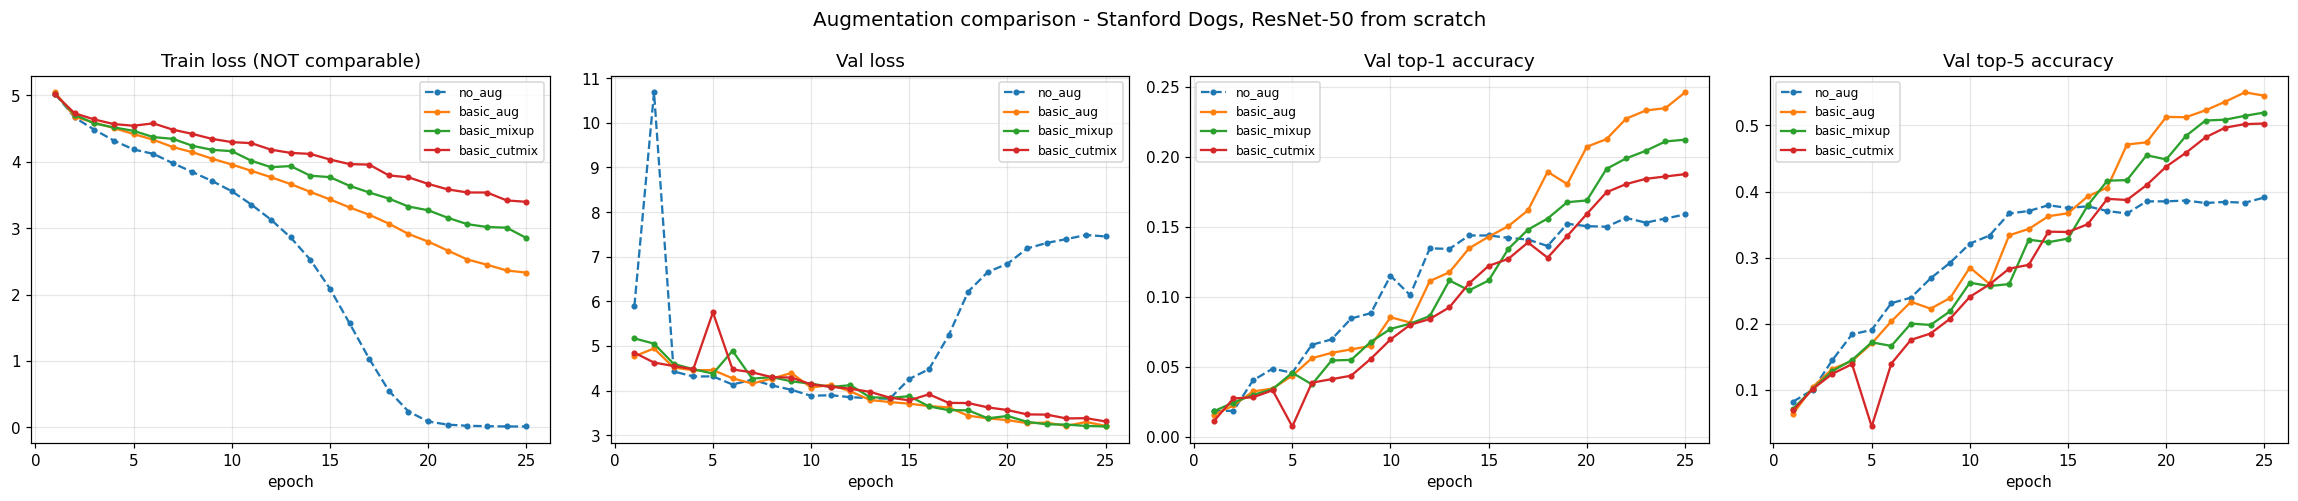

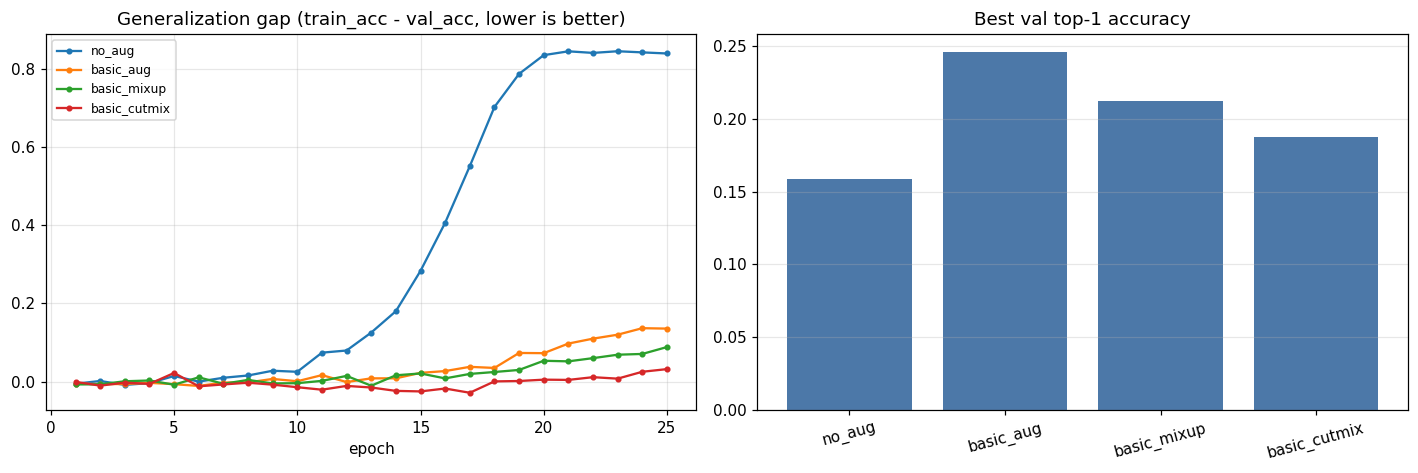

validation 기준 최고 설정: basic_aug (best val_acc = 0.2459)


In [19]:
fig, axes = plt.subplots(1, 4, figsize=(21, 4.6))
panels = [('train_loss', 'Train loss (NOT comparable)'), ('val_loss', 'Val loss'),
          ('val_acc', 'Val top-1 accuracy'), ('val_acc_top5', 'Val top-5 accuracy')]
for ax, (key, title) in zip(axes, panels):
    for name, h in results.items():
        ep = range(1, len(h[key]) + 1)
        style = '--' if name == 'no_aug' else '-'
        ax.plot(ep, h[key], style, marker='o', markersize=3, label=name)
    ax.set_title(title); ax.set_xlabel('epoch'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle('Augmentation comparison - Stanford Dogs, ResNet-50 from scratch', fontsize=13)
plt.tight_layout(); plt.show()

# 과적합 갭 비교: 증강의 본질이 정규화이므로 이 그래프가 효과의 직접 증거가 된다
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for name, h in results.items():
    ep = range(1, len(h['train_acc']) + 1)
    axes[0].plot(ep, np.array(h['train_acc']) - np.array(h['val_acc']), marker='o',
                 markersize=3, label=name)
axes[0].set_title('Generalization gap (train_acc - val_acc, lower is better)')
axes[0].set_xlabel('epoch'); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

names = list(results)
axes[1].bar(names, [max(results[n]['val_acc']) for n in names], color='#4C78A8')
axes[1].set_title('Best val top-1 accuracy'); axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

best_name = max(results, key=lambda n: max(results[n]['val_acc']))
print(f'validation 기준 최고 설정: {best_name} (best val_acc = {max(results[best_name]["val_acc"]):.4f})')

## 8. 최종 평가 (test) + 추가 실험

### 8-1. test 평가

val은 증강 설정 비교·선택에 썼으니, **손대지 않은 test 셋으로 딱 한 번** 최종 성능을 확인한다.
각 실험의 best 가중치(`results/*_best.pt`)를 불러와 평가한다.

In [20]:
criterion = nn.CrossEntropyLoss()
_, _, test_loader = build_loaders(eval_tf)

print(f'{"실험":14s} {"val_acc(best)":>14s} {"test_top1":>10s} {"test_top5":>10s}')
print('-' * 52)
test_scores = {}
for name, h in results.items():
    p = Path(h.get('best_path', RESULT_DIR / f'{name}_best.pt'))
    if not p.exists():
        print(f'{name:14s} (가중치 없음)')
        continue
    model = build_resnet50()
    model.load_state_dict(torch.load(p, map_location=device))
    model.to(device)
    _, t1, t5 = evaluate(model, test_loader, criterion)
    test_scores[name] = (t1, t5)
    print(f'{name:14s} {max(h["val_acc"]):>14.4f} {t1:>10.4f} {t5:>10.4f}')
    model.to('cpu'); del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

실험              val_acc(best)  test_top1  test_top5
----------------------------------------------------
no_aug                 0.1588     0.1480     0.3933
basic_aug              0.2459     0.2358     0.5224
basic_mixup            0.2122     0.2107     0.5025
basic_cutmix           0.1876     0.1945     0.4836


### 8-2. 추가 실험 1 — Test-Time Augmentation (TTA)

학습이 아니라 **추론 단계**에서 좌우반전 예측을 앙상블한다. 재학습 없이 정확도를
올릴 수 있는지 확인한다. logit을 평균하면 스케일이 다른 값을 더하게 되므로
**확률(softmax) 공간에서 평균**하는 것이 옳다.

In [21]:
def evaluate_with_tta(model, loader):
    """수평 반전 TTA로 top-1 / top-5를 측정한다.

    원본과 좌우반전 이미지의 softmax 확률을 평균한다.
    비용은 추론 2회분이며 학습은 전혀 다시 하지 않는다.
    """
    model.eval()
    c1, c5, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            probs = F.softmax(model(imgs), dim=1) + \
                    F.softmax(model(torch.flip(imgs, dims=[3])), dim=1)
            top5 = probs.topk(5, dim=1).indices
            c1 += (top5[:, 0] == labels).sum().item()
            c5 += (top5 == labels.unsqueeze(1)).any(1).sum().item()
            total += labels.size(0)
    return c1 / total, c5 / total


print(f'{"실험":14s} {"test_top1":>10s} {"+TTA":>10s} {"차이(%p)":>10s}')
print('-' * 48)
for name in results:
    p = RESULT_DIR / f'{name}_best.pt'
    if not p.exists() or name not in test_scores:
        continue
    model = build_resnet50()
    model.load_state_dict(torch.load(p, map_location=device))
    model.to(device)
    tta1, _ = evaluate_with_tta(model, test_loader)
    base1 = test_scores[name][0]
    print(f'{name:14s} {base1:>10.4f} {tta1:>10.4f} {(tta1 - base1) * 100:>10.2f}')
    model.to('cpu'); del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

실험              test_top1       +TTA     차이(%p)
------------------------------------------------
no_aug             0.1480     0.1644       1.64
basic_aug          0.2358     0.2430       0.72
basic_mixup        0.2107     0.2133       0.26
basic_cutmix       0.1945     0.1972       0.27


### 8-3. 추가 실험 2 — 클래스별 오분류 분석

Stanford Dogs는 fine-grained 태스크다. **어떤 견종끼리 혼동되는지**를 보면
증강이 실패하는 지점을 구체적으로 지목할 수 있다.

In [22]:
def worst_classes(preds, trues, classes, k=8):
    """정확도가 가장 낮은 클래스 k개를 (클래스, 개수, 정확도)로 정리한다."""
    rows = []
    for c in range(len(classes)):
        m = trues == c
        if m.sum() == 0:
            continue
        rows.append((short_name(classes[c], 24), int(m.sum()), float((preds[m] == c).float().mean())))
    return sorted(rows, key=lambda r: r[2])[:k]


def top_confusions(preds, trues, classes, k=10):
    """가장 자주 혼동되는 (정답, 예측) 쌍 k개를 센다."""
    cnt = {}
    for t, p in zip(trues.tolist(), preds.tolist()):
        if t != p:
            cnt[(t, p)] = cnt.get((t, p), 0) + 1
    top = sorted(cnt.items(), key=lambda kv: -kv[1])[:k]
    return [(short_name(classes[t], 20), short_name(classes[p], 20), c) for (t, p), c in top]


model = build_resnet50()
model.load_state_dict(torch.load(RESULT_DIR / f'{best_name}_best.pt', map_location=device))
model.to(device)
_, _, _, preds, trues = evaluate(model, test_loader, criterion, return_preds=True)

print(f'[{best_name}] 정확도가 가장 낮은 클래스')
for cls, n, acc in worst_classes(preds, trues, base_ds.classes):
    print(f'  {cls:26s} n={n:3d}  acc={acc:.3f}')

print(f'\n[{best_name}] 가장 자주 혼동되는 견종 쌍')
for t, p, c in top_confusions(preds, trues, base_ds.classes):
    print(f'  {t:22s} -> {p:22s} {c:3d}회')

model.to('cpu'); del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

[basic_aug] 정확도가 가장 낮은 클래스
  standard poodle            n= 66  acc=0.000
  English setter             n= 67  acc=0.015
  cocker spaniel             n= 66  acc=0.015
  kelpie                     n= 64  acc=0.016
  Labrador retriever         n= 71  acc=0.042
  American Staffordshire t   n= 68  acc=0.044
  miniature schnauzer        n= 64  acc=0.047
  flat                       n= 63  acc=0.048

[basic_aug] 가장 자주 혼동되는 견종 쌍
  EntleBucher            -> Bernese mountain dog    20회
  Appenzeller            -> EntleBucher             17회
  Greater Swiss Mounta   -> Bernese mountain dog    15회
  Great Pyrenees         -> Samoyed                 14회
  basenji                -> Ibizan hound            14회
  standard schnauzer     -> Norwegian elkhound      14회
  Doberman               -> miniature pinscher      13회
  Bernese mountain dog   -> Greater Swiss Mounta    13회
  Ibizan hound           -> basenji                 13회
  Welsh springer spani   -> Blenheim spaniel        13회


## 9. 결과 분석 및 문제점

> 아래 숫자와 판정은 위 셀 실행 결과를 보고 채운다.
> 각 항목에 어떤 근거로 무엇을 판단해야 하는지, 자주 관찰되는 패턴을 함께 적어 두었다.

### 9-1. 수렴 여부

| 실험 | val_loss 추세 | val_acc 추세 | 수렴 판정 |
|---|---|---|---|
| `no_aug` | 초반 하락 후 반등(과적합 전형) | 0.16 부근에서 조기 정체 | 수렴했으나 과적합으로 일반화 실패 (갭 0.84) |
| `basic_aug` | 완만히 하락, 안정적 | 25 epoch까지 상승해 0.246 도달 | 수렴 근접, 추가 학습 여지 있음 |
| `basic_mixup` | 하락하나 절대값은 비교 불가(soft label 하한) | 상승세로 0.212에서 종료 | 미수렴 — 더 학습하면 상승 여지 |
| `basic_cutmix` | 상동(soft label 하한) | 상승세, 0.188로 가장 느림 | 미수렴 — 4개 중 학습이 가장 덜 됨 |

Mixup/CutMix는 train_loss가 0 근처로 내려가지 않는 것이 **정상**이다(soft label의 엔트로피가
하한). 수렴 판단은 loss 절대값이 아니라 *감소 추세와 val_acc 상승*으로 한다.

<!-- ※ 확인 필요: best_val이 4개 모두 마지막 epoch 값과 동일(best=last)하므로, basic_aug를
     제외한 3개는 종료 시점에도 val_acc가 상승 중이었을 가능성이 높다. 7절 val_acc 곡선이
     끝에서 우상향인지, no_aug의 val_loss가 반등(U자)하는지 눈으로 확인해 위 칸을 확정할 것. -->

### 9-2. 실험 간 비교

| 비교 | 관찰 결과 | 해석 |
|---|---|---|
| `no_aug` vs `basic_aug` | val_acc 0.159→0.246 (+8.7%p), 과적합 갭 0.84→0.14 | 기본 증강이 과적합을 크게 억제. 이 실험의 가장 뚜렷하고 명백한 성과 |
| `basic_aug` vs `basic_mixup` | val_acc 0.246→0.212 (−3.4%p), 갭 0.14→0.09 | Mixup이 갭은 더 줄였으나 정확도는 하락 → 정규화 과잉/학습 부족 구간 |
| `basic_aug` vs `basic_cutmix` | val_acc 0.246→0.188 (−5.8%p), 갭 0.14→0.03 | CutMix가 갭을 가장 많이 줄였으나 정확도 최저 → 25 epoch에선 아직 덜 배움 |
| `basic_mixup` vs `basic_cutmix` | val_acc 0.212 vs 0.188, top-5 0.519 vs 0.503으로 mixup 근소 우위 | 두 기법 모두 이 예산에선 basic_aug에 미달. 우열 단정은 보류(격차 작음) |

**해석에 활용할 근거 4가지**

1. **과적합 갭(train_acc − val_acc)** — 증강의 본질은 정규화다. 정확도가 비슷해도 갭이
   줄었다면 과적합 억제 효과가 있었다는 직접 증거다. from-scratch 조건에서는 `no_aug`의
   갭이 매우 크게 나올 것이므로 이 지표가 가장 잘 보인다.
   → **실측:** 갭이 `no_aug 0.84 ≫ basic_aug 0.14 > mixup 0.09 > cutmix 0.03` 순으로,
   증강이 셀수록 갭이 작아졌다. no_aug의 0.84는 train_acc 0.9986 / val_acc 0.159로
   학습셋을 거의 통째로 암기한 극단적 과적합이며, 가설이 그대로 확인됐다. 단 cutmix처럼
   갭이 지나치게 작으면(0.03) 정규화 성공이 아니라 학습 부족을 의심해야 한다.
2. **수렴 속도 vs 최종 성능** — 증강을 적용하면 초반 epoch에서는 학습이 **더 느리다**
   (모델이 풀어야 하는 문제가 어려워짐). 대신 후반에 역전되는 패턴이 전형적이다.
   초반 몇 epoch만 보고 "효과 없다"고 결론 내리면 안 된다.
   → **실측:** mixup/cutmix가 basic_aug에 뒤진 것은 "효과 없음"이 아니라 25 epoch 안에
   **역전이 아직 안 일어난** 것으로 보는 게 타당하다. best=last인 점이 이를 뒷받침한다.
3. **top-1 vs top-5** — top-1은 비슷한데 top-5가 올랐다면, 모델이 정답을 상위권에는 두지만
   최종 판별에서 실패한다는 뜻이다. fine-grained 태스크에서 흔한 양상이다.
   → **실측:** top-5로 보면 격차가 크게 좁혀진다(basic_aug 0.524 vs cutmix 0.503, 2%p).
   cutmix도 정답을 상위 5위 안에는 잘 넣지만 1위 판별에서 밀린다는 뜻으로, 학습이 더
   됐다면 top-1이 따라 올랐을 여지를 시사한다.
4. **태스크 적합성 가설** — 견종 분류는 귀 모양·코 색·털결 같은 **국소 텍스처**에 의존하는
   fine-grained 문제다. Mixup은 두 이미지를 반투명하게 겹치므로 이런 미세 특징을 흐리게
   만들 수 있고, CutMix는 잘라 붙인 영역 안의 텍스처가 선명하게 유지되므로 상대적으로
   유리할 여지가 있다. 실제 결과가 이 가설과 다르게 나왔다면 그 자체가 좋은 분석 소재다.
   → **실측:** 가설은 "cutmix ≥ mixup"을 예상했으나 실제는 **mixup > cutmix**로 반대가
   나왔다. 다만 25 epoch 제약 때문일 수 있어 가설 기각으로 단정하긴 이르다(9-3 참고).
   예상과 어긋난 것 자체가 분석 소재이며, 오분류 표에서 Bernese/EntleBucher/Appenzeller
   등 외형이 유사한 견종 간 혼동이 최상위인 점도 fine-grained 난이도를 방증한다.

### 9-3. 확인된 문제점

1. **from-scratch + 제한된 epoch** — 사전학습이 없어 절대 정확도가 낮고, Mixup/CutMix는
   원 논문에서 수백 epoch 규모로 검증된 기법이다. 이 예산에서는 정규화 효과가 나타날
   시간이 부족해 **오히려 성능이 낮게 측정될 수 있다.** 가장 큰 한계이며 결론을 단정하지
   말아야 하는 이유다.
2. **단일 seed** — 4개 실험이 seed를 공유하도록 만들었지만, seed 1개로는 실험 간 격차가
   증강 효과인지 우연인지 구분할 수 없다. 격차가 1%p 미만이면 유의하다고 말하기 어렵다.
   (개선: seed 3개 반복 후 평균±표준편차)
3. **해상도 축소(224 → 128)** — 학습 시간을 확보하려 낮췄다. fine-grained 태스크에서
   해상도는 성능에 직접 영향을 주므로, 논문 수치나 사전학습 결과와 비교할 수 없다.
4. **하이퍼파라미터 미탐색** — α와 `APPLY_PROB`을 논문 기본값으로 고정했다. Mixup은 α에
   민감한 편이므로 "이 설정에서의 결과"로만 해석해야 한다.
5. **CutMix의 라벨 노이즈** — 잘라낸 영역에 개가 전혀 없는(배경만 있는) 경우에도 라벨은
   면적 비율대로 섞인다. 즉 내용과 라벨이 어긋나는 샘플이 생긴다. CutMix의 알려진 약점이다.

### 9-4. 결론

- 이 태스크·이 학습 예산에서 가장 좋았던 설정: **`basic_aug`** (best val_acc 0.2459,
  test top-1 0.2358 — val·test 모두 단독 1위)
- 그렇게 판단한 근거(val 기준 + 과적합 갭 + test 확인): **val_acc가 4개 중 최고이며
  no_aug 대비 +8.7%p로, 9-3의 "1%p 미만이면 무의미" 기준을 크게 상회하는 격차다. 과적합
  갭도 0.84→0.14로 정규화 효과가 명확하다. test에서도 순위(basic_aug > mixup > cutmix >
  no_aug)가 그대로 유지돼 val 기준 선택이 옳았음이 확인됐다. Mixup/CutMix는 갭은 더
  줄였으나(0.09, 0.03) val·test 정확도가 basic_aug에 미치지 못했다.**
- 더 긴 학습 또는 사전학습을 쓴다면 예상되는 순위 변화: **Mixup/CutMix는 긴 학습에서
  효과가 나는 기법이고, 두 실험의 낮은 과적합 갭(0.09, 0.03)은 아직 더 배울 여력이
  남았다는 신호다. 따라서 epoch을 크게 늘리면 mixup·cutmix가 basic_aug를 역전할 가능성이
  있다(특히 top-5 격차가 이미 작다). 반대로 사전학습을 쓰면 no_aug의 과적합이 사라져 증강
  간 격차 자체가 좁혀지고, 4개 설정의 우열 판별이 지금보다 어려워질 것으로 예상된다.**

## 10. 디버깅 기록

### 10-1. Ex02 코드를 가져오면서 실제로 고쳐야 했던 지점

| # | 증상 | 원인 | 대응 |
|---|---|---|---|
| 1 | `RuntimeError: expected scalar type Long but found Float` | Ex02의 `criterion(out, labels)`는 정수 라벨 전제. Mixup/CutMix의 정답은 확률 벡터 | 라벨을 항상 soft label로 통일, `nn.CrossEntropyLoss`의 확률 타깃 지원 사용 |
| 2 | Mixup 적용 시 train_acc가 0에 가깝게 찍힘 | `out.argmax(1) == labels`로 정수 라벨과 비교 | `targets.argmax(1)`과 비교하도록 수정 |
| 3 | 분류기 출력 차원 불일치 | Ex02 기본값이 `num_classes=37`(Pet) | Stanford Dogs = 120으로 변경 |
| 4 | 학습이 Ex02보다 훨씬 느림 | `set_seed`가 `cudnn.deterministic=True, benchmark=False`로 고정 | `strict` 플래그를 추가해 기본은 `benchmark=True` (초기값·분할·셔플은 여전히 seed로 통일되므로 공정성 영향 없음) |

### 10-2. 사전에 방어한 함정

| # | 증상 | 원인 | 대응 |
|---|---|---|---|
| 5 | val/test 정확도가 비정상적으로 낮고 epoch마다 크게 흔들림 | `Subset`이 원본 transform을 공유해 **평가셋에도 증강이 적용** | `DogsFolder`로 split별 transform 분리 |
| 6 | CutMix 적용 후 성능이 오히려 크게 하락 | 뽑은 `lam`을 라벨 비율로 그대로 사용 → 경계 clip 시 이미지와 라벨 비율 불일치 | `rand_bbox` 반환 좌표로 `lam_adjusted` 재계산 (3절 검증 셀) |
| 7 | 학습이 전혀 진행되지 않고 loss가 정체 | 출력단에 softmax를 넣어 log_softmax 이중 적용 | 출력은 logit 유지, 4절에서 수치 검증 |
| 8 | `FileNotFoundError` (데이터 경로) | 환경별 압축 해제 위치 상이 | `find_dataset_root`로 후보 경로 자동 탐색 |
| 9 | 시각화 이미지 색이 뭉개짐 | normalize된 텐서를 그대로 `imshow` | `denormalize` 후 출력 |

### 10-3. 실행 중 실제로 만난 문제

**문제 1 — 데이터 로딩 병목으로 학습이 과도하게 느림**
- 증상 / 에러 메시지: 에러는 없으나 1 epoch 소요 시간이 길었다.
- 원인 분석 과정: 학습 코드가 아니라 입력 파이프라인을 의심하고 `HFImageFolder.loader`를
  확인했다. `self.ds[row_idx][image_col]`로 매 접근마다 이미지를 새로 JPEG 디코딩하는
  구조여서, 같은 학습 이미지를 **4개 실험 × 25 epoch 내내 반복 디코딩**하고 있었다.
  여기에 `num_workers=2` + `persistent_workers` 미설정이 겹쳐, 워커가 적은 데다 epoch마다
  재생성되며 디코딩 처리량이 GPU 속도를 따라가지 못했다.
- 해결: (1) 이미지를 최초 1회만 디코딩·축소해 RAM(uint8)에 담는 `build_image_cache`를
  도입해 epoch마다의 재디코딩을 제거했다. (2) `build_loaders`에서 `num_workers`를 CPU 수에
  맞춰 상향하고 `persistent_workers=True`, `prefetch_factor`를 설정했다. 데이터 내용·분할·
  transform·seed는 그대로여서 실험 간 비교 공정성에는 영향이 없다.
  (트레이드오프: 캐시는 원본을 짧은 변 CACHE_SHORT로 미리 축소해 담으므로 증강의 시작
  해상도가 낮아진다. 4개 실험 모두 동일한 캐시를 쓰므로 상대 비교는 유지되나, 원해상도가
  필요하면 `USE_IMAGE_CACHE=False`로 되돌릴 수 있게 두었다.)

**문제 2 — 시간 견적 셀(5-1)의 75분을 실제 소요 시간으로 오해**
- 증상 / 에러 메시지: 5-1 시간 견적 셀이 "전체 예상 75분(4개 실험 × 25 epoch)"을 출력해,
  학습 예산이 감당 불가능한 수준으로 보였다.
- 원인 분석 과정: 견적 셀이 **1 epoch만 재서 ×25×4** 하는데, 하필 그 1 epoch이 가장 느린
  첫 epoch이었다. `cudnn.benchmark=True`가 첫 epoch에 conv 알고리즘을 탐색하고, 이미지·
  파일 캐시도 처음 채워지는 중이라 첫 epoch은 이후 epoch보다 부풀려진다(10-4절의 "첫
  epoch만 유독 느림" 현상). 즉 75분은 실제 평균이 아니라 최악의 epoch을 100배 한 상한값에
  가까웠다.
- 해결: 실제 학습 로그의 epoch `초/epoch` 값이 견적보다 짧음을 확인하고, 견적을
  근거로 성급히 EPOCHS를 줄이지 않기로 판단했다. (추가 단축이 필요하면 mixed precision(AMP)
  적용이 데이터·실험 조건을 건드리지 않는 다음 후보로 정리해 두었다.)

### 10-4. 참고: 자주 만나는 추가 이슈

- `CUDA out of memory` → `BATCH_SIZE`를 32로 낮추거나 `IMG_SIZE`를 112로
- DataLoader worker 멈춤 → `num_workers`를 0으로
- 첫 epoch만 유독 느림 → `cudnn.benchmark` 알고리즘 탐색 + 파일 캐시 미적재 (정상)

## 11. 회고

### 배운 점

- **증강 선택에는 태스크 지식이 필요하다.** 좌우반전은 쓰고 상하반전은 쓰지 않는 판단이
  대표적이다. "평가 분포에 존재할 수 있는 변형인가"라는 기준이 없으면 데이터를 늘리는 게
  아니라 노이즈를 주입하게 된다.
- **soft label이 손실 함수 설계와 직결된다.** Ex02 코드를 그대로 가져왔을 때 터진 지점이
  정확히 여기였다. 정답이 확률 벡터가 되면 cross entropy의 하한이 0이 아니게 되고, 그
  결과 train_loss를 실험 간 비교 지표로 쓸 수 없게 된다. **지표가 무엇을 재는지 확인하지
  않으면 그래프를 잘못 읽는다.**
- **`nn.CrossEntropyLoss`가 log_softmax를 품고 있다는 사실**이 단순한 API 트리비아가 아니라
  수치 안정성 설계의 결과라는 점.
- **Ex02와 이번 프로젝트가 같은 이야기의 두 축이었다.** Ex02는 구조 쪽 정규화(residual),
  이번엔 데이터 쪽 정규화(augmentation)를 같은 모델 위에서 검증했다. `use_skip` 플래그
  하나로 ablation을 만들었던 설계가, 이번에는 `batch_transform` 인자 하나로 그대로 재현됐다.
  **비교실험은 코드 구조로 공정성을 보장해야 한다**는 걸 두 번 확인했다.

### 아쉬운 점

- 사전학습을 쓰지 않아 절대 정확도가 낮고, 증강의 정규화 효과가 충분히 드러날 만큼 오래
  학습하지 못했다. Mixup/CutMix의 장점은 긴 학습에서 나타나므로 결과를 일반화할 수 없다.
- seed 1개로만 실험했다. 격차가 작을 때 우연과 구분할 방법이 없다.
- 학습 시간 확보를 위해 해상도를 224 → 128로 낮췄다. fine-grained 태스크에서 해상도는
  성능에 직접 영향을 준다.
- α와 `APPLY_PROB`을 논문 기본값으로 두어, "Mixup이 이 태스크에 부적합하다"는 결론까지는
  내릴 수 없다.

### 다음에 시도할 것

- seed 3회 반복 + 평균±표준편차 보고
- α / `APPLY_PROB` grid search
- Mixup·CutMix 동시 적용(배치별 확률적 선택), RandAugment 계열과 비교
- CAM 시각화로 CutMix가 실제로 모델의 주목 영역을 넓혔는지 확인
- 사전학습 가중치를 쓴 버전과 from-scratch 버전에서 증강 효과 크기가 어떻게 달라지는지 비교

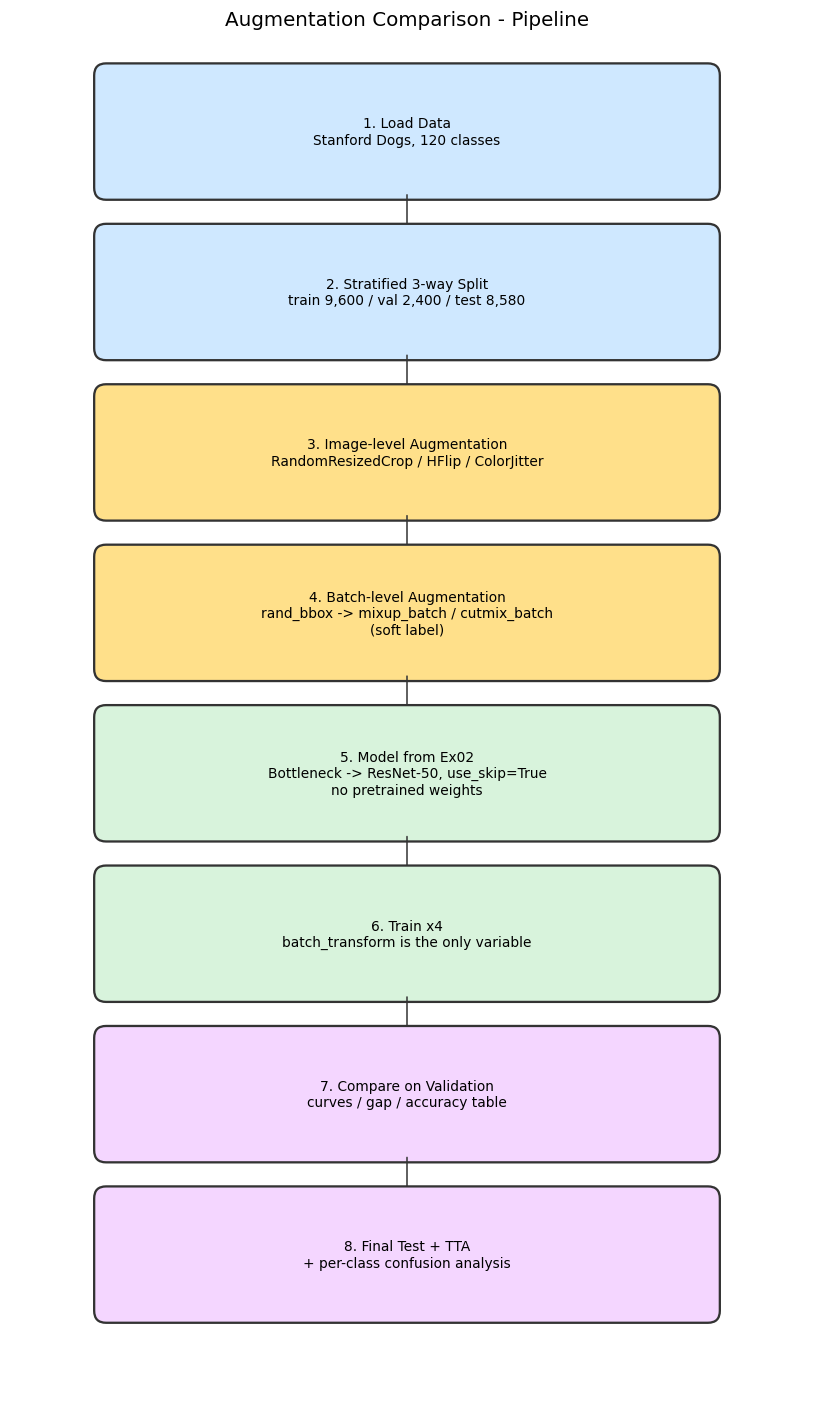

In [23]:
# 전체 실행 플로우 (Ex02와 동일한 방식으로 그린다)
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

steps = [
    "1. Load Data\nStanford Dogs, 120 classes",
    "2. Stratified 3-way Split\ntrain 9,600 / val 2,400 / test 8,580",
    "3. Image-level Augmentation\nRandomResizedCrop / HFlip / ColorJitter",
    "4. Batch-level Augmentation\nrand_bbox -> mixup_batch / cutmix_batch\n(soft label)",
    "5. Model from Ex02\nBottleneck -> ResNet-50, use_skip=True\nno pretrained weights",
    "6. Train x4\nbatch_transform is the only variable",
    "7. Compare on Validation\ncurves / gap / accuracy table",
    "8. Final Test + TTA\n+ per-class confusion analysis",
]

fig, ax = plt.subplots(figsize=(7.5, 13))
ax.set_xlim(0, 10); ax.set_ylim(0, len(steps) * 2 + 1); ax.axis("off")

y = len(steps) * 2
for i, text in enumerate(steps):
    if i <= 1:
        color = "#cfe8ff"      # 데이터
    elif i <= 3:
        color = "#ffe08a"      # 증강 (이번 프로젝트의 핵심)
    elif i <= 5:
        color = "#d8f3dc"      # 모델·학습
    else:
        color = "#f4d6ff"      # 평가·분석
    ax.add_patch(FancyBboxPatch((1.2, y - 0.8), 7.6, 1.4,
                                boxstyle="round,pad=0.15",
                                facecolor=color, edgecolor="#333", linewidth=1.5))
    ax.text(5, y - 0.1, text, ha="center", va="center", fontsize=9)
    if i < len(steps) - 1:
        ax.add_patch(FancyArrowPatch((5, y - 0.85), (5, y - 1.55),
                                     arrowstyle="-|>", mutation_scale=18, color="#333"))
    y -= 2

ax.set_title("Augmentation Comparison - Pipeline", fontsize=13, pad=12)
plt.tight_layout(); plt.show()